In [37]:

import os
import glob
import pickle
import re
from collections import defaultdict
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import seaborn as sns
sns.set_style("whitegrid")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
# Root folder — one sub-directory per subject, e.g. data/NF/002GNV/
DATA_ROOT = "../../../Data/"

FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

In [39]:
import sys, pathlib
project_root = pathlib.Path.cwd().parent  # parent of notebooks/
sys.path.append(str(project_root))

from utils.metrics import (
    load_subject,
)

In [40]:
def discover_subjects(data_root):
    """Return sorted list of subject IDs (= sub-folder names) in data_root."""
    return sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    )


# --- Discover and load all subjects ---
subject_ids = discover_subjects(DATA_ROOT)
print(f"Subjects found: {subject_ids}\n")

# all_data[subject_id] = {"sessions": ..., "yeo_labels": ...}
all_data = {}
for sid in subject_ids:
    sessions, yeo_labels = load_subject(DATA_ROOT, sid)
    all_data[sid] = {"sessions": sessions, "yeo_labels": yeo_labels}

print(f"\nLoaded {len(all_data)} subject(s).")

Subjects found: ['002GNV', '003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']

  002GNV: 15 session file(s)
  003GNV: 15 session file(s)
  004GNV: 15 session file(s)
  005GNV: 15 session file(s)
  008GNV: 15 session file(s)
  012GNV: 15 session file(s)
  013GNV: 15 session file(s)
  016GNV: 15 session file(s)
  020GNV: 15 session file(s)
  021GNV: 15 session file(s)
  023GNV: 15 session file(s)
  025GNV: 15 session file(s)
  026GNV: 15 session file(s)
  034GNV: 15 session file(s)
  037GNV: 15 session file(s)
  041GNV: 15 session file(s)
  043GNV: 15 session file(s)
  048GNV: 15 session file(s)
  049GNV: 15 session file(s)
  054GNV: 15 session file(s)
  056GNV: 15 session file(s)

Loaded 21 subject(s).


In [41]:
def upper_triangular_vector(mat):
    assert mat.shape[0] == mat.shape[1]
    iu = np.triu_indices(mat.shape[0], k=1)
    return mat[iu]

def build_fc_dataframe_from_alldata(alldata):
    rows = []
    for sid, subj in alldata.items():
        sessions = subj['sessions']
        for sess_id, runs in sessions.items():
            for run_id, rd in runs.items():
                FC = rd['FC']
                cond = rd.get('condition', None)
                fc_vec = upper_triangular_vector(FC)
                rows.append({
                    'subject': sid,
                    'session': sess_id,
                    'run': run_id,
                    'condition': cond,
                    'fc_vec': fc_vec
                })
    return pd.DataFrame(rows)

fc_df = build_fc_dataframe_from_alldata(all_data)
print(fc_df.head())
print("Number of rows (subject-session-run):", len(fc_df))

  subject session   run condition  \
0  002GNV     V01  Run1  Feedback   
1  002GNV     V01  Run2  Feedback   
2  002GNV     V01  Run3  Feedback   
3  002GNV     V01  Run4  Feedback   
4  002GNV     V01  Run5  Feedback   

                                              fc_vec  
0  [0.7504682137406573, 0.5589357800410456, 0.757...  
1  [0.7275835913937682, 0.5453920504670445, 0.740...  
2  [0.7303229990013944, 0.6279139231349821, 0.767...  
3  [0.4479924150450744, 0.46767185956806473, 0.65...  
4  [0.8560361697431812, 0.8033028178591572, 0.877...  
Number of rows (subject-session-run): 1990


In [42]:
def similarity_corr(tg_mat, db_mat):
    """
    Pearson correlation between each target FC vector and each database FC vector.
    tg_mat: (N_tg, E), db_mat: (N_db, E).
    Returns sim: (N_tg, N_db).
    """
    X = np.vstack([tg_mat, db_mat])
    C = np.corrcoef(X)
    N_tg = tg_mat.shape[0]
    return C[:N_tg, N_tg:]

In [43]:
def identification_accuracy_per_session(df, db_session, tg_session, label_col='subject'):
    """
    Finn-style identification at subject×session level:
    - For each subject and session, average fc_vec across runs → 1 FC per subject per session.
    - Database: all subjects in db_session.
    - Target: all subjects in tg_session.
    """
    # collapse runs within subject×session
    grouped = (
        df
        .groupby([label_col, 'session'])['fc_vec']
        .apply(lambda v: np.mean(np.vstack(v.values), axis=0))
        .reset_index()
    )

    db = grouped[grouped['session'] == db_session].reset_index(drop=True)
    tg = grouped[grouped['session'] == tg_session].reset_index(drop=True)

    db_mat = np.vstack(db['fc_vec'].values)   # (N_db_subj, E)
    tg_mat = np.vstack(tg['fc_vec'].values)   # (N_tg_subj, E)

    sim = similarity_corr(tg_mat, db_mat)     # (N_tg_subj, N_db_subj)

    db_labels = db[label_col].values
    tg_labels = tg[label_col].values

    predicted = db_labels[sim.argmax(axis=1)]
    acc = (predicted == tg_labels).mean()
    return acc, sim, tg_labels, predicted


# Per-session, Finn-style: one FC per subject per session
acc_sess, sim_sess, true_sess, pred_sess = identification_accuracy_per_session(
    fc_df,
    db_session='V01',
    tg_session='V15',
    label_col='subject'
)
print(f"Identification accuracy (per-session): {acc_sess:.2%}")

Identification accuracy (per-session): 95.24%


In [44]:
def identification_accuracy_per_session_per_network(
    df,
    db_session,
    tg_session,
    net_mask,
    label_col='subject'
):
    """
    Per-session Finn-style identification restricted to a subset of edges (one network).

    net_mask: 1D boolean array of length E selecting edges belonging to the network
              (e.g. frontoparietal). Same ordering as fc_vec.
    """
    # collapse runs to one FC per subject×session (same as above)
    grouped = (
        df
        .groupby([label_col, 'session'])['fc_vec']
        .apply(lambda v: np.mean(np.vstack(v.values), axis=0))
        .reset_index()
    )

    db = grouped[grouped['session'] == db_session].reset_index(drop=True)
    tg = grouped[grouped['session'] == tg_session].reset_index(drop=True)

    # apply network mask to edge vectors
    db_mat = np.vstack([vec[net_mask] for vec in db['fc_vec'].values])  # (N_db_subj, E_net)
    tg_mat = np.vstack([vec[net_mask] for vec in tg['fc_vec'].values])  # (N_tg_subj, E_net)

    sim = similarity_corr(tg_mat, db_mat)  # Pearson r over network edges only

    db_labels = db[label_col].values
    tg_labels = tg[label_col].values

    predicted = db_labels[sim.argmax(axis=1)]
    acc = (predicted == tg_labels).mean()
    return acc, sim, tg_labels, predicted

In [45]:
# node labels 1..9 from your data
example_subj = list(all_data.keys())[0]
yeo_labels = np.array(all_data[example_subj]['yeo_labels'])  # 1..9

# keep 1..7, drop 8,9 by setting to -1; then shift 1..7 -> 0..6
yeo_labels = np.where((yeo_labels >= 1) & (yeo_labels <= 7),
                      yeo_labels - 1,
                      -1)

N = len(yeo_labels)
i_idx, j_idx = np.triu_indices(N, k=1)
E = len(i_idx)

# check fc_vec length
assert len(fc_df['fc_vec'].iloc[0]) == E

# build masks in a compact loop
yeo_edge_masks = {}
for net_id, name in enumerate(YEO_NAMES):  # 0..6
    nodes = (yeo_labels == net_id)
    mask = nodes[i_idx] & nodes[j_idx]
    yeo_edge_masks[name] = mask

for name in YEO_NAMES:
    mask = yeo_edge_masks[name]
    print(name, "edges:", mask.sum())

Visual edges: 406
Somatomotor edges: 595
Dorsal Attention edges: 325
Ventral Attention edges: 231
Limbic edges: 66
Frontoparietal edges: 435
Default edges: 1035


In [66]:
len(fc_df['fc_vec'].iloc[0])

23871

In [46]:
acc_fp, sim_fp, true_fp, pred_fp = identification_accuracy_per_session_per_network(
    fc_df,
    db_session='V01',
    tg_session='V15',
    net_mask=yeo_edge_masks["Frontoparietal"],
    label_col='subject'
)
print(f"Frontoparietal per-session ID V01 → V15: {acc_fp:.3f}")

Frontoparietal per-session ID V01 → V15: 1.000


### Finn-style identification (run / session level)

We follow Finn et al. to compute identification accuracy from FC vectors:

- For each **target** FC vector $f^{(t)}_i$ and each **database** FC vector $f^{(d)}_j$, compute a similarity matrix using Pearson correlation over edges:

$$
\text{sim}_{ij} = \text{corr}\big(f^{(t)}_i, f^{(d)}_j\big).
$$

- For each target $i$, assign the predicted identity

$$
\hat{s}_i = \arg\max_j \text{sim}_{ij},
$$

and compare $\hat{s}_i$ to the true subject label $s_i$.

- Identification accuracy is the fraction of targets with $\hat{s}_i = s_i$.

When database and target contain the **same rows** (within-session ID), we mask the diagonal of $\text{sim}$ (set to $-\infty$) before argmax, to avoid trivial self-matches.

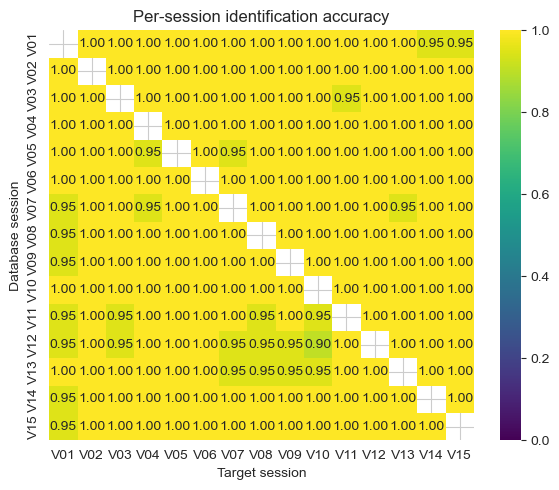

In [47]:
sessions = sorted(fc_df['session'].unique())
n_sess = len(sessions)

acc_mat = np.zeros((n_sess, n_sess))

for i, db_s in enumerate(sessions):
    for j, tg_s in enumerate(sessions):
        if db_s == tg_s:
            acc_mat[i, j] = np.nan  # or skip; Finn only uses different days
            continue
        acc, _, _, _ = identification_accuracy_per_session(
            fc_df, db_session=db_s, tg_session=tg_s, label_col='subject'
        )
        acc_mat[i, j] = acc

plt.figure(figsize=(6, 5))
sns.heatmap(acc_mat, annot=True, fmt=".2f",
            xticklabels=sessions, yticklabels=sessions,
            vmin=0, vmax=1, cmap='viridis')
plt.xlabel("Target session")
plt.ylabel("Database session")
plt.title("Per-session identification accuracy")
plt.tight_layout()

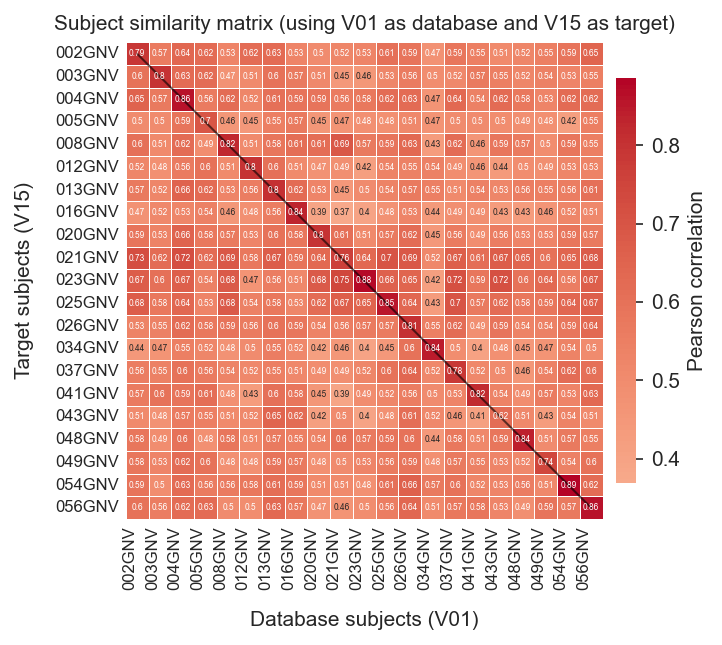

In [48]:
db_sess = 'V01'
tg_sess = 'V15'

# sim_sess: rows = target subjects (V15), columns = database subjects (V01)
acc_sess, sim_sess, true_lab, pred_lab = identification_accuracy_per_session(
    fc_df, db_session=db_sess, tg_session=tg_sess, label_col='subject'
)

# 1) Get the common subject list, sorted
subjects = sorted(np.unique(true_lab))   # should match subjects in db_sess

# 2) Row order: where each subject appears in true_lab (target session)
row_order = np.array([np.where(true_lab == s)[0][0] for s in subjects])

# 3) Column order: get db labels for db_sess in the same subject order
db_acc, _, db_lab, _ = identification_accuracy_per_session(
    fc_df, db_session=db_sess, tg_session=db_sess, label_col='subject'
)
col_order = np.array([np.where(db_lab == s)[0][0] for s in subjects])

# 4) Reorder similarity matrix so rows/cols both follow `subjects`
sim_ordered = sim_sess[row_order][:, col_order]

# 5) Prettier plot
fig, ax = plt.subplots(figsize=(5.4, 4.4), dpi=150)

hm = sns.heatmap(
    sim_ordered,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=np.min(sim_ordered),
    vmax=np.max(sim_ordered),
    square=True,
    linewidths=0.4,
    linecolor='white',
    xticklabels=subjects,
    yticklabels=subjects,
    annot=True,
    annot_kws={"size": 4},
    cbar_kws={
        'label': 'Pearson correlation',
        'shrink': 0.85,
        'pad': 0.02
    }
)

# Axis labels and title
ax.set_xlabel(f'Database subjects ({db_sess})', fontsize=10, labelpad=10)
ax.set_ylabel(f'Target subjects ({tg_sess})', fontsize=10, labelpad=10)
ax.set_title(
    f'Subject similarity matrix (using {db_sess} as database and {tg_sess} as target)',
    fontsize=10,
)

# Ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.tick_params(length=0)

# Draw a diagonal guide to highlight the expected match positions
n = sim_ordered.shape[0]
ax.plot(np.arange(n) + 0.5, np.arange(n) + 0.5, color='black', lw=1.0, alpha=0.6)

# Clean up spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()



### Network-restricted identification

To measure how informative a single network is:

- Build a boolean mask over edges for the network of interest (e.g. frontoparietal).
- Apply this mask to each FC vector, keeping only those edges.
- Run the same Finn-style identification procedure on the masked vectors.

The resulting accuracy tells you how well that network alone can fingerprint subjects.

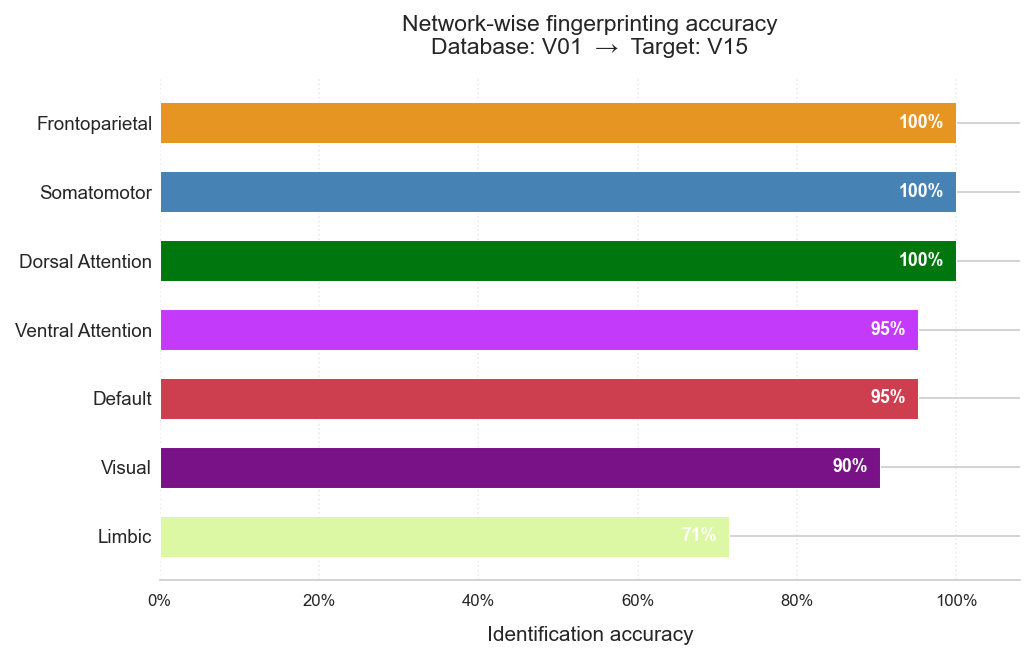

In [49]:
db_sess = 'V01'
tg_sess = 'V15'

acc_whole, _, _, _ = identification_accuracy_per_session(
    fc_df, db_session=db_sess, tg_session=tg_sess, label_col='subject'
)

acc_per_net = []
for name in YEO_NAMES:
    mask = yeo_edge_masks[name]
    acc_net, _, _, _ = identification_accuracy_per_session_per_network(
        fc_df,
        db_session=db_sess,
        tg_session=tg_sess,
        net_mask=mask,
        label_col='subject'
    )
    acc_per_net.append(acc_net)

# Sort networks by accuracy
net_df = pd.DataFrame({'network': YEO_NAMES, 'acc': acc_per_net})
net_df = net_df.sort_values('acc', ascending=True)  # ascending for horizontal barh

# Standard Yeo-7 colors
yeo_colors = {
    'Visual':            '#781286',
    'Somatomotor':       '#4682B4',
    'Dorsal Attention':  '#00760E',
    'Ventral Attention': '#C43AFA',
    'Limbic':            '#DCF8A4',
    'Frontoparietal':    '#E69422',
    'Default':           '#CD3E4E',
}

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

bar_colors = [yeo_colors[n] for n in net_df['network']]
bars = ax.barh(
    net_df['network'], net_df['acc'],
    color=bar_colors,
    height=0.6,
    edgecolor='white',
    linewidth=0.5,
    zorder=3,
)



# Value labels on bars
for bar, val in zip(bars, net_df['acc']):
    label_x = val - 0.015 if val > 0.12 else val + 0.008
    ha = 'right' if val > 0.12 else 'left'
    color = 'white' if val > 0.12 else '#333333'
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            f'{val:.0%}', va='center', ha=ha, fontsize=8.5,
            fontweight='bold', color=color)

# Whole-brain bar label
ax.text(acc_whole - 0.015, len(net_df),
        f'{acc_whole:.0%}', va='center', ha='right',
        fontsize=8.5, fontweight='bold', color='white')

ax.set_xlim(0, 1.08)
ax.set_xlabel('Identification accuracy', fontsize=10, labelpad=8)
ax.set_title(
    f'Network-wise fingerprinting accuracy\n'
    f'Database: {db_sess}  →  Target: {tg_sess}',
    fontsize=11, pad=12
)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=9)
ax.tick_params(axis='x', labelsize=8)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle=':', alpha=0.4, zorder=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'network_id_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()


### Differential identifiability $I_{\text{diff}}$

Let $A$ be the $N \times N$ **identifiability matrix**, where $A_{ij}$ is the Pearson correlation between the FC of subject $i$ in the **test** session and subject $j$ in the **retest** session.

Define:
- $I_{\text{self}} = \text{mean}(\text{diag}(A))$: average within-subject test–retest correlation.
- $I_{\text{others}} = \text{mean}(A_{ij} \mid i \neq j)$: average between-subject correlation.

$$
I_{\text{diff}} = 100 \times \big( I_{\text{self}} - I_{\text{others}} \big).
$$

High $I_{\text{diff}}$ means same-subject similarity is much larger than cross-subject similarity, i.e. strong connectome fingerprinting.


In [50]:
def differential_identifiability(
    fc_df,
    test_session,
    retest_session,
    label_col='subject',
    net_mask=None
):
    """
    Computes Amico & Goñi's differential identifiability:
    I_self = mean within-subject correlation
    I_others = mean between-subject correlation
    I_diff = 100 * (I_self - I_others)
    """

    if net_mask is None:
        # whole brain
        acc, sim, tg_labels, _ = identification_accuracy_per_session(
            fc_df,
            db_session=test_session,
            tg_session=retest_session,
            label_col=label_col
        )
        acc_test, _, test_labels, _ = identification_accuracy_per_session(
            fc_df,
            db_session=test_session,
            tg_session=test_session,
            label_col=label_col
        )
    else:
        acc, sim, tg_labels, _ = identification_accuracy_per_session_per_network(
            fc_df,
            db_session=test_session,
            tg_session=retest_session,
            net_mask=net_mask,
            label_col=label_col
        )
        acc_test, _, test_labels, _ = identification_accuracy_per_session_per_network(
            fc_df,
            db_session=test_session,
            tg_session=test_session,
            net_mask=net_mask,
            label_col=label_col
        )

    subjects = sorted(np.unique(tg_labels))
    row_idx = np.array([np.where(tg_labels == s)[0][0] for s in subjects])
    col_idx = np.array([np.where(test_labels == s)[0][0] for s in subjects])
    A = sim[row_idx][:, col_idx]

    N = A.shape[0]
    diag = np.diag(A)
    I_self = diag.mean()
    off = A[~np.eye(N, dtype=bool)]
    I_others = off.mean()
    I_diff = 100 * (I_self - I_others)

    return I_self, I_others, I_diff, A

In [51]:
I_self, I_others, I_diff, A = differential_identifiability(
    fc_df,
    test_session='V01',
    retest_session='V15',
    label_col='subject'
)
print(I_self, I_others, I_diff)

0.8046292915633657 0.5516448581845627 25.298443337880304


In [52]:
def build_fc_matrix(fc_df, sessions, label_col='subject'):
    """
    Returns:
      X: (E, S) array, columns = session FCs
      meta: DataFrame with columns ['subject','session'] for each column of X
    """
    df_sub = fc_df[fc_df['session'].isin(sessions)].copy()

    # one row per subject×session (after averaging runs, if needed)
    grouped = (
        df_sub
        .groupby([label_col, 'session'])['fc_vec']
        .apply(lambda v: np.mean(np.vstack(v.values), axis=0))
        .reset_index()
    )

    # sort for a stable order
    grouped = grouped.sort_values([label_col, 'session']).reset_index(drop=True)

    # stack vectors into columns
    mat = np.vstack(grouped['fc_vec'].values)        # shape (S, E)
    X = mat.T                                        # (E, S)

    meta = grouped[[label_col, 'session']].copy()
    return X, meta

sessions = ['V01', 'V15']  # or your REST1/REST2, etc.
X, meta = build_fc_matrix(fc_df, sessions, label_col='subject')

### PCA reconstruction and $I_{\text{diff}}(m)$

We stack vectorized FCs (one per subject–session) into a matrix

$$
X \in \mathbb{R}^{E \times S},
$$

where $E$ is the number of edges and $S$ is the number of sessions.

1. Center across sessions:

$$
X_{\text{centered}} = X - \bar{X},
$$

where $\bar{X}$ is the mean across columns.

2. Run PCA on $X_{\text{centered}}^\top$ to obtain:
   - `scores` (one row per session, coordinates in PC space),
   - `components` (PC loadings, one row per component, length $E$).

3. For a given number of components $m$, reconstruct:

$$
X_{\text{rec}}^{(m)} = \bar{X} + \text{components}_{1:m}^\top \cdot \text{scores}_{1:m}^\top.
$$

4. Convert $X_{\text{rec}}^{(m)}$ back to subject–session FCs, build the identifiability matrix $A$, and compute $I_{\text{self}}, I_{\text{others}}, I_{\text{diff}}$ as above.

By sweeping $m$ and taking the m that maximizes $I_{\text{diff}}$, we get the **optimal PCA reconstruction** that maximizes identifiability for that pair of sessions.

In [53]:
from sklearn.decomposition import PCA

# center data (PCA will also center internally, but this makes reconstruction explicit)
X_mean = X.mean(axis=1, keepdims=True)
X_centered = X - X_mean

# full PCA across sessions
pca = PCA(n_components=min(X_centered.shape[0], X_centered.shape[1]), svd_solver='full')
scores = pca.fit_transform(X_centered.T)   # shape: (S, K)
components = pca.components_               # shape: (K, E)
expl_var = pca.explained_variance_ratio_
K_max = scores.shape[1]

In [54]:
def reconstruct_X_m(X_mean, scores, components, m):
    # scores[:, :m] = (S, m), components[:m, :] = (m, E)
    X_rec_centered = scores[:, :m] @ components[:m, :]   # (S, E)
    X_rec = X_rec_centered.T + X_mean                    # (E, S)
    return X_rec

In [55]:
def differential_identifiability_from_X_rec(X_rec, meta, test_session, retest_session, label_col='subject'):
    """
    X_rec: (E, S) reconstructed FCs
    meta: DataFrame with columns [label_col,'session'] for each column (S entries)
    """
    # turn back into (S, E) FC rows
    mat = X_rec.T  # (S, E)

    # split test and retest
    is_test = meta['session'] == test_session
    is_retest = meta['session'] == retest_session

    mat_test = mat[is_test.values]      # (N, E)
    mat_retest = mat[is_retest.values]  # (N, E)

    subj_test = meta.loc[is_test, label_col].values
    subj_retest = meta.loc[is_retest, label_col].values

    # reorder both to same subject order
    subjects = sorted(np.unique(subj_test))
    idx_test = np.array([np.where(subj_test == s)[0][0] for s in subjects])
    idx_retest = np.array([np.where(subj_retest == s)[0][0] for s in subjects])

    mat_test_ord = mat_test[idx_test]
    mat_retest_ord = mat_retest[idx_retest]

    # correlation between every test and every retest subject (A: N x N)
    # use similarity_corr-like function
    X_ = np.vstack([mat_retest_ord, mat_test_ord])
    C_ = np.corrcoef(X_)
    N = mat_retest_ord.shape[0]
    A = C_[:N, N:]   # rows=retest, cols=test

    # I_self, I_others, I_diff
    diag = np.diag(A)
    I_self = diag.mean()
    off = A[~np.eye(N, dtype=bool)]
    I_others = off.mean()
    I_diff = 100 * (I_self - I_others)

    return I_self, I_others, I_diff, A

In [56]:
test_session = 'V01'
retest_session = 'V15'

m_values = [2, 5] + list(range(10, min(K_max, 160)+1, 10))
results = []

for m in m_values:
    X_rec = reconstruct_X_m(X_mean, scores, components, m)
    I_self, I_others, I_diff, A = differential_identifiability_from_X_rec(
        X_rec, meta,
        test_session=test_session,
        retest_session=retest_session,
        label_col='subject'
    )
    results.append({'m': m, 'I_self': I_self, 'I_others': I_others, 'I_diff': I_diff})

results_df = pd.DataFrame(results)
m_star = results_df.loc[results_df['I_diff'].idxmax(), 'm']
I_diff_star = results_df['I_diff'].max()
print("Optimal m* =", m_star, "I_diff* =", I_diff_star)

Optimal m* = 20 I_diff* = 32.35973737303913


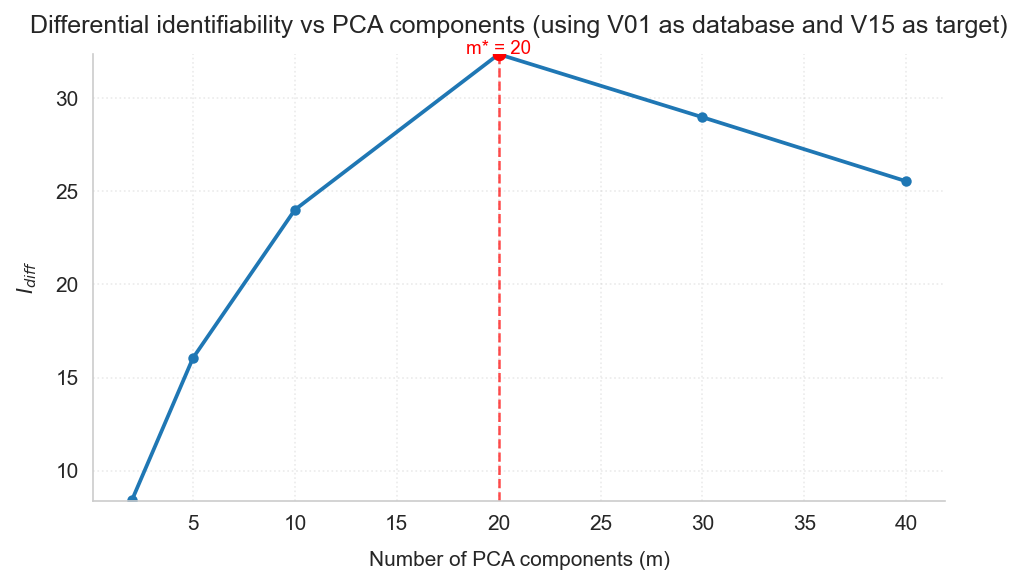

In [57]:
m_values = [2, 5] + list(range(10, min(scores.shape[1], 160)+1, 10))

I_self_list = []
I_others_list = []
I_diff_list = []

for m in m_values:
    X_rec = reconstruct_X_m(X_mean, scores, components, m)
    I_self, I_others, I_diff, A = differential_identifiability_from_X_rec(
        X_rec, meta,
        test_session=test_session,
        retest_session=retest_session,
        label_col='subject'
    )
    I_self_list.append(I_self)
    I_others_list.append(I_others)
    I_diff_list.append(I_diff)

m_star = m_values[int(np.argmax(I_diff_list))]
I_diff_star = max(I_diff_list)

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=150)

# Main curve
ax.plot(
    m_values, I_diff_list,
    marker='o', markersize=4,
    linewidth=1.8,
    color='tab:blue',
    label=r'$I_{diff}$'
)

# Highlight optimal point
ax.axvline(m_star, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.scatter(m_star, I_diff_star, color='red', s=30, zorder=3)

# Annotate optimal m
ax.text(
    m_star, I_diff_star + 0.01,
    f'm* = {m_star}',
    color='red',
    fontsize=9,
    ha='center'
)

# Labels and title
ax.set_xlabel('Number of PCA components (m)', labelpad=8)
ax.set_ylabel(r'$I_{diff}$', labelpad=8)
ax.set_title(
    f'Differential identifiability vs PCA components (using {db_sess} as database and {tg_sess} as target)',
    pad=10
)

# Grid and styling
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: tighten y-limits slightly around data
ymin = min(I_diff_list) - 0.02
ymax = max(I_diff_list) + 0.02
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()

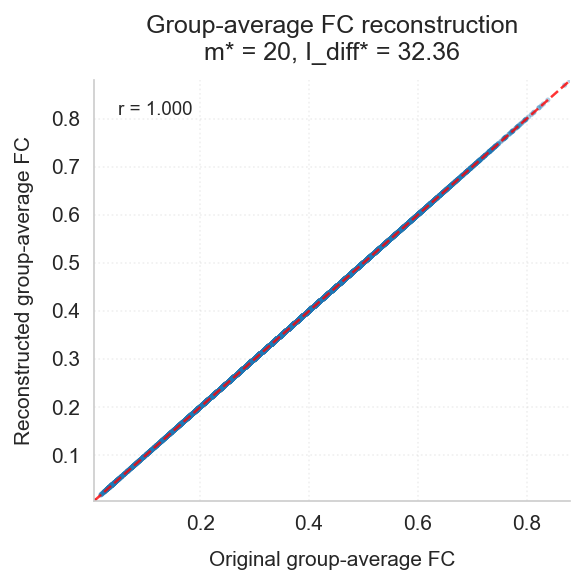

In [58]:
# choose optimal m*
X_rec_star = reconstruct_X_m(X_mean, scores, components, m_star)

# original group-average FC (across all sessions in X)
FC_orig = X.mean(axis=1)
FC_rec  = X_rec_star.mean(axis=1)

fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

# Scatter (slightly transparent, nicer color)
ax.scatter(
    FC_orig, FC_rec,
    s=6,
    alpha=0.35,
    edgecolors='none'
)

# Identity line
lims = [
    min(FC_orig.min(), FC_rec.min()),
    max(FC_orig.max(), FC_rec.max())
]
ax.plot(lims, lims, linestyle='--', linewidth=1.2, color='red', alpha=0.8)
ax.set_xlim(lims)
ax.set_ylim(lims)

# Labels and title
ax.set_xlabel('Original group-average FC', labelpad=8)
ax.set_ylabel('Reconstructed group-average FC', labelpad=8)
ax.set_title(
    f'Group-average FC reconstruction\nm* = {m_star}, I_diff* = {I_diff_star:.2f}',
    pad=10
)

# Optional: show correlation in corner
r = np.corrcoef(FC_orig, FC_rec)[0, 1]
ax.text(
    0.05, 0.95,
    f'r = {r:.3f}',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9
)

# Grid + clean look
ax.grid(True, linestyle=':', alpha=0.3)
ax.set_axisbelow(True)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [59]:
def build_run_similarity_matrix(fc_df, label_col='subject'):
    """
    Compute Pearson correlation between every pair of runs 
    across all subjects and sessions.
    Returns:
      sim_mat : (N_runs, N_runs) correlation matrix
      run_labels : list of (subject, session, run) for each row/col
    """
    # stable ordering
    df_sorted = fc_df.sort_values([label_col, 'session', 'run']).reset_index(drop=True)
    
    fc_mat = np.vstack(df_sorted['fc_vec'].values)   # (N_runs, E)
    sim_mat = np.corrcoef(fc_mat)                     # (N_runs, N_runs)
    
    run_labels = list(zip(
        df_sorted[label_col],
        df_sorted['session'],
        df_sorted['run']
    ))
    
    return sim_mat, run_labels, df_sorted


sim_mat, run_labels, df_sorted = build_run_similarity_matrix(fc_df)

print(f"Matrix shape: {sim_mat.shape}")
print(f"Total runs: {len(run_labels)}")

Matrix shape: (1990, 1990)
Total runs: 1990


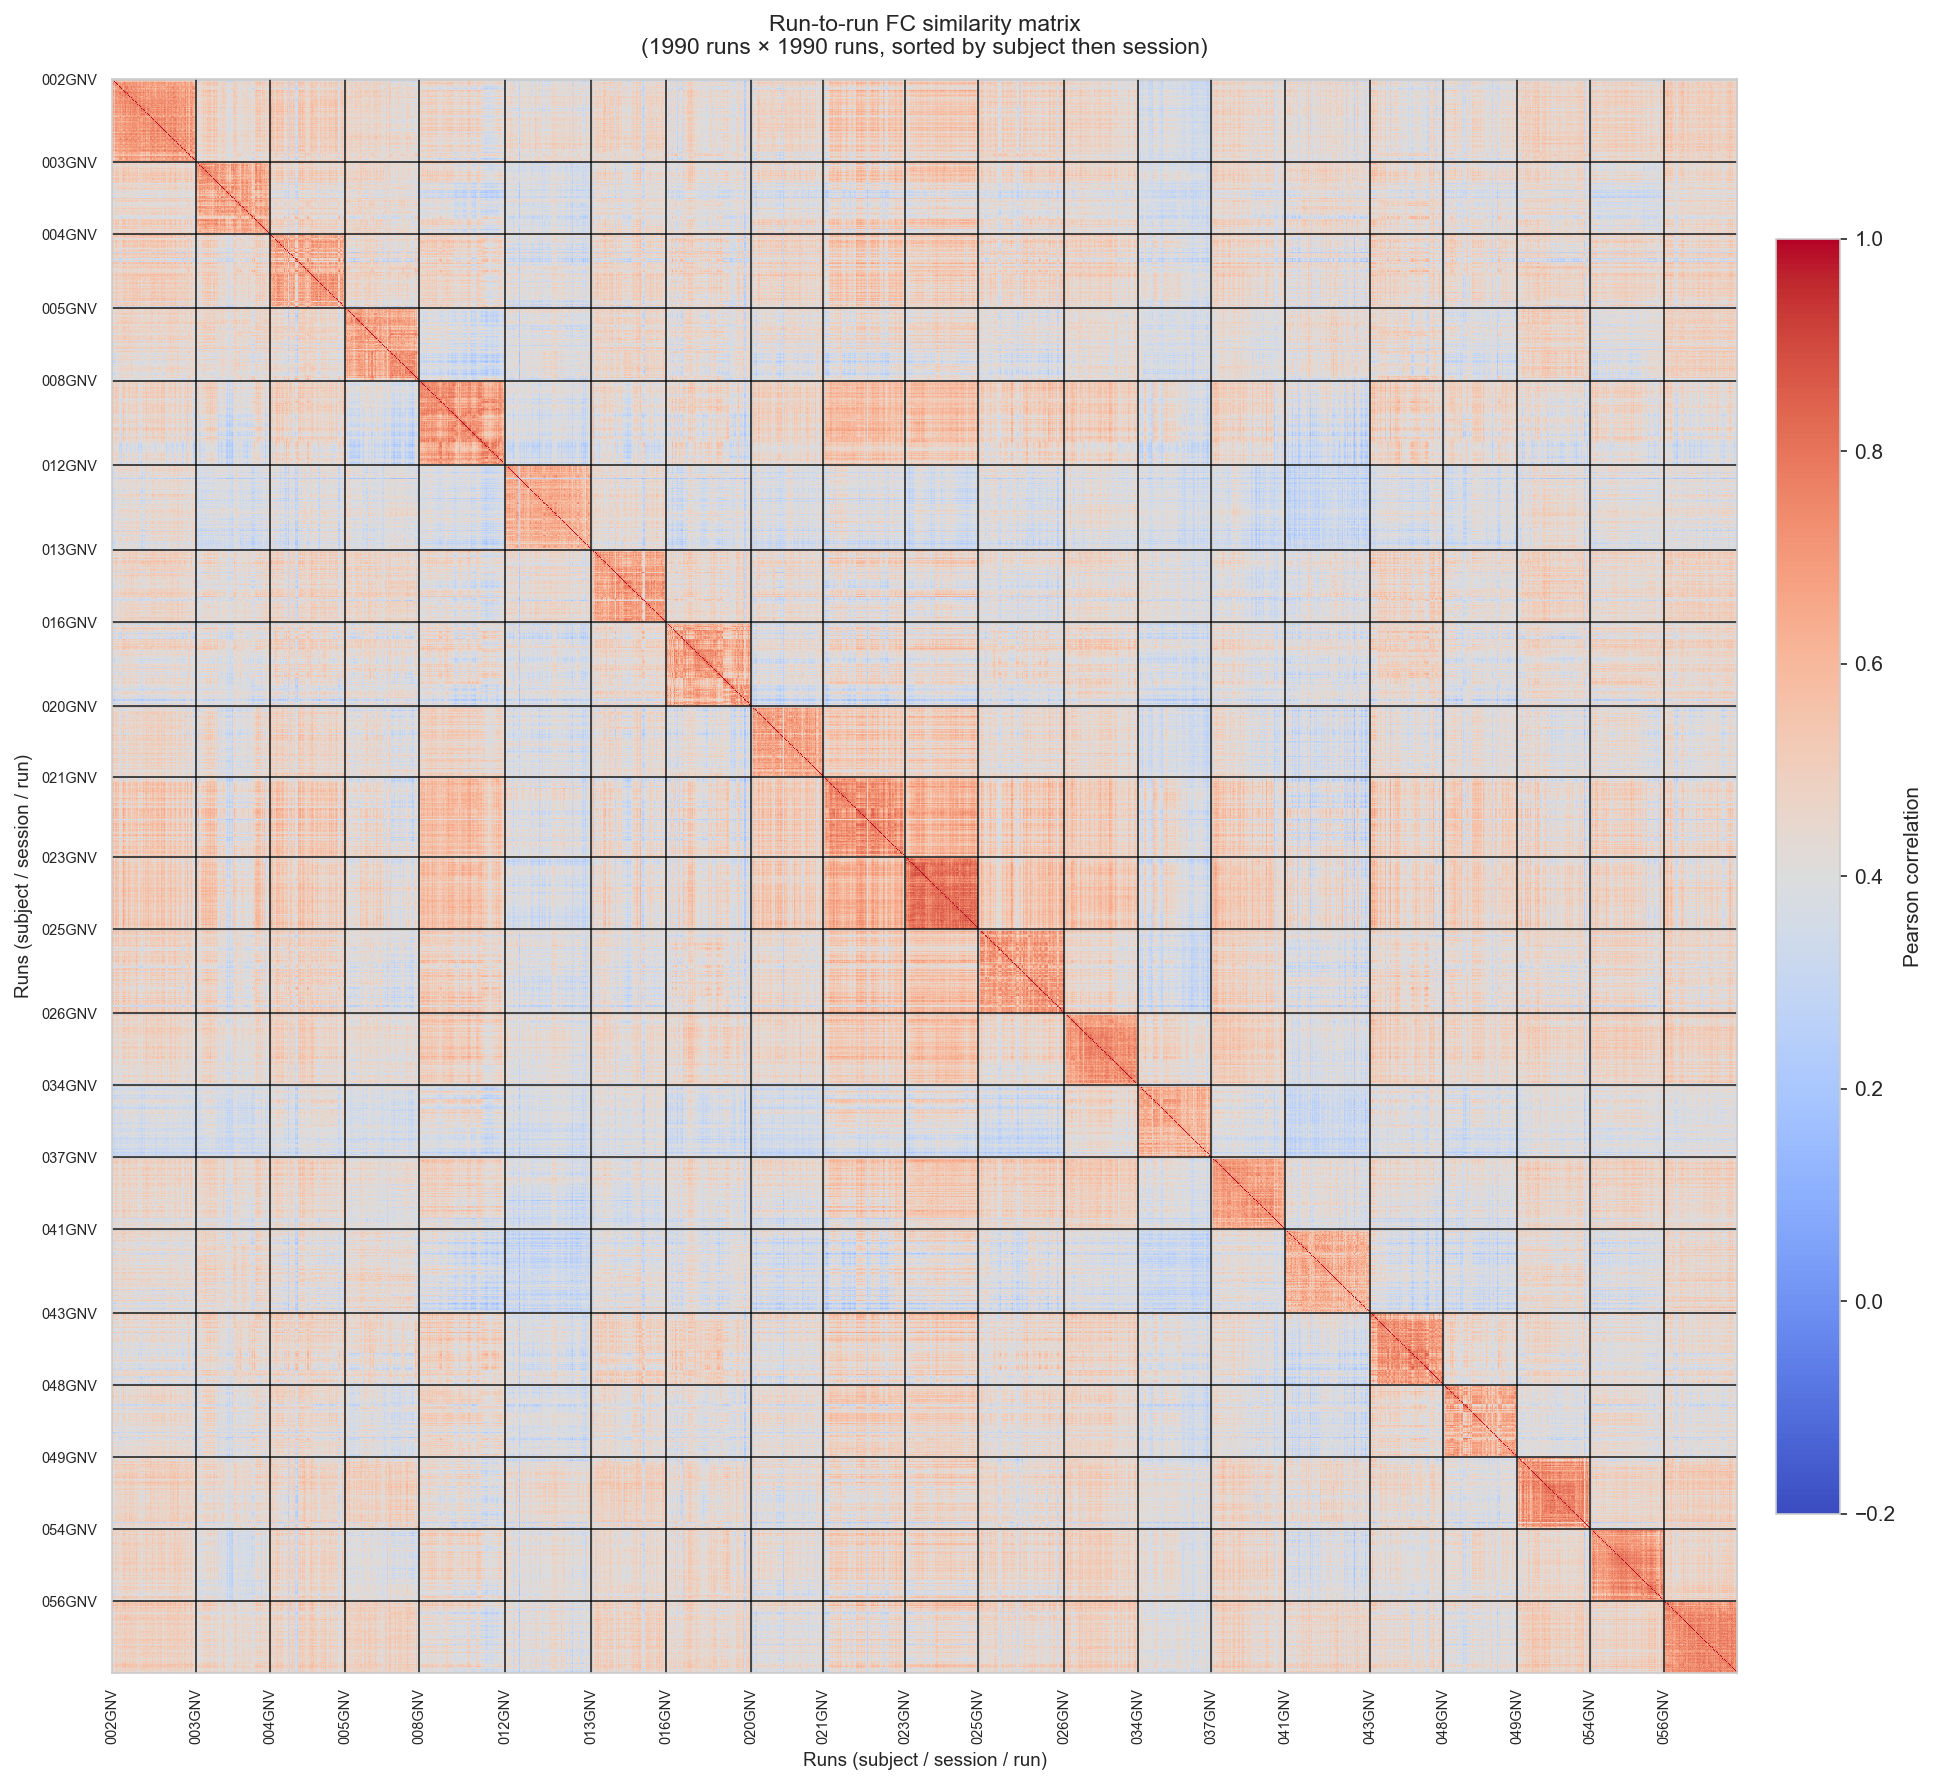

In [60]:
# ── Plot ──────────────────────────────────────────────────────────────────────
subjects = df_sorted['subject'].values
sessions = df_sorted['session'].values

# tick labels: show subject ID only at the first run of each subject
n_runs = len(run_labels)
tick_labels = []
tick_pos    = []
for i, (subj, sess, run) in enumerate(run_labels):
    if i == 0 or subjects[i] != subjects[i-1]:
        tick_labels.append(subj)
        tick_pos.append(i)

# boundary positions between subjects (for dividing lines)
subj_boundaries = [
    i for i in range(1, n_runs)
    if subjects[i] != subjects[i-1]
]

fig, ax = plt.subplots(figsize=(14, 12), dpi=150)

im = ax.imshow(
    sim_mat,
    cmap='coolwarm',
    vmin=-0.2, vmax=1.0,
    aspect='auto',
    interpolation='none'
)

# subject boundary lines
for b in subj_boundaries:
    ax.axhline(b - 0.5, color='black', linewidth=0.8, alpha=0.8)
    ax.axvline(b - 0.5, color='black', linewidth=0.8, alpha=0.8)

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Pearson correlation', fontsize=10)

# ticks at subject boundaries
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=7)
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_labels, fontsize=7)

ax.set_title(
    f'Run-to-run FC similarity matrix\n'
    f'({n_runs} runs × {n_runs} runs, sorted by subject then session)',
    fontsize=11, pad=12
)
ax.set_xlabel('Runs (subject / session / run)', fontsize=9)
ax.set_ylabel('Runs (subject / session / run)', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'run_to_run_similarity_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

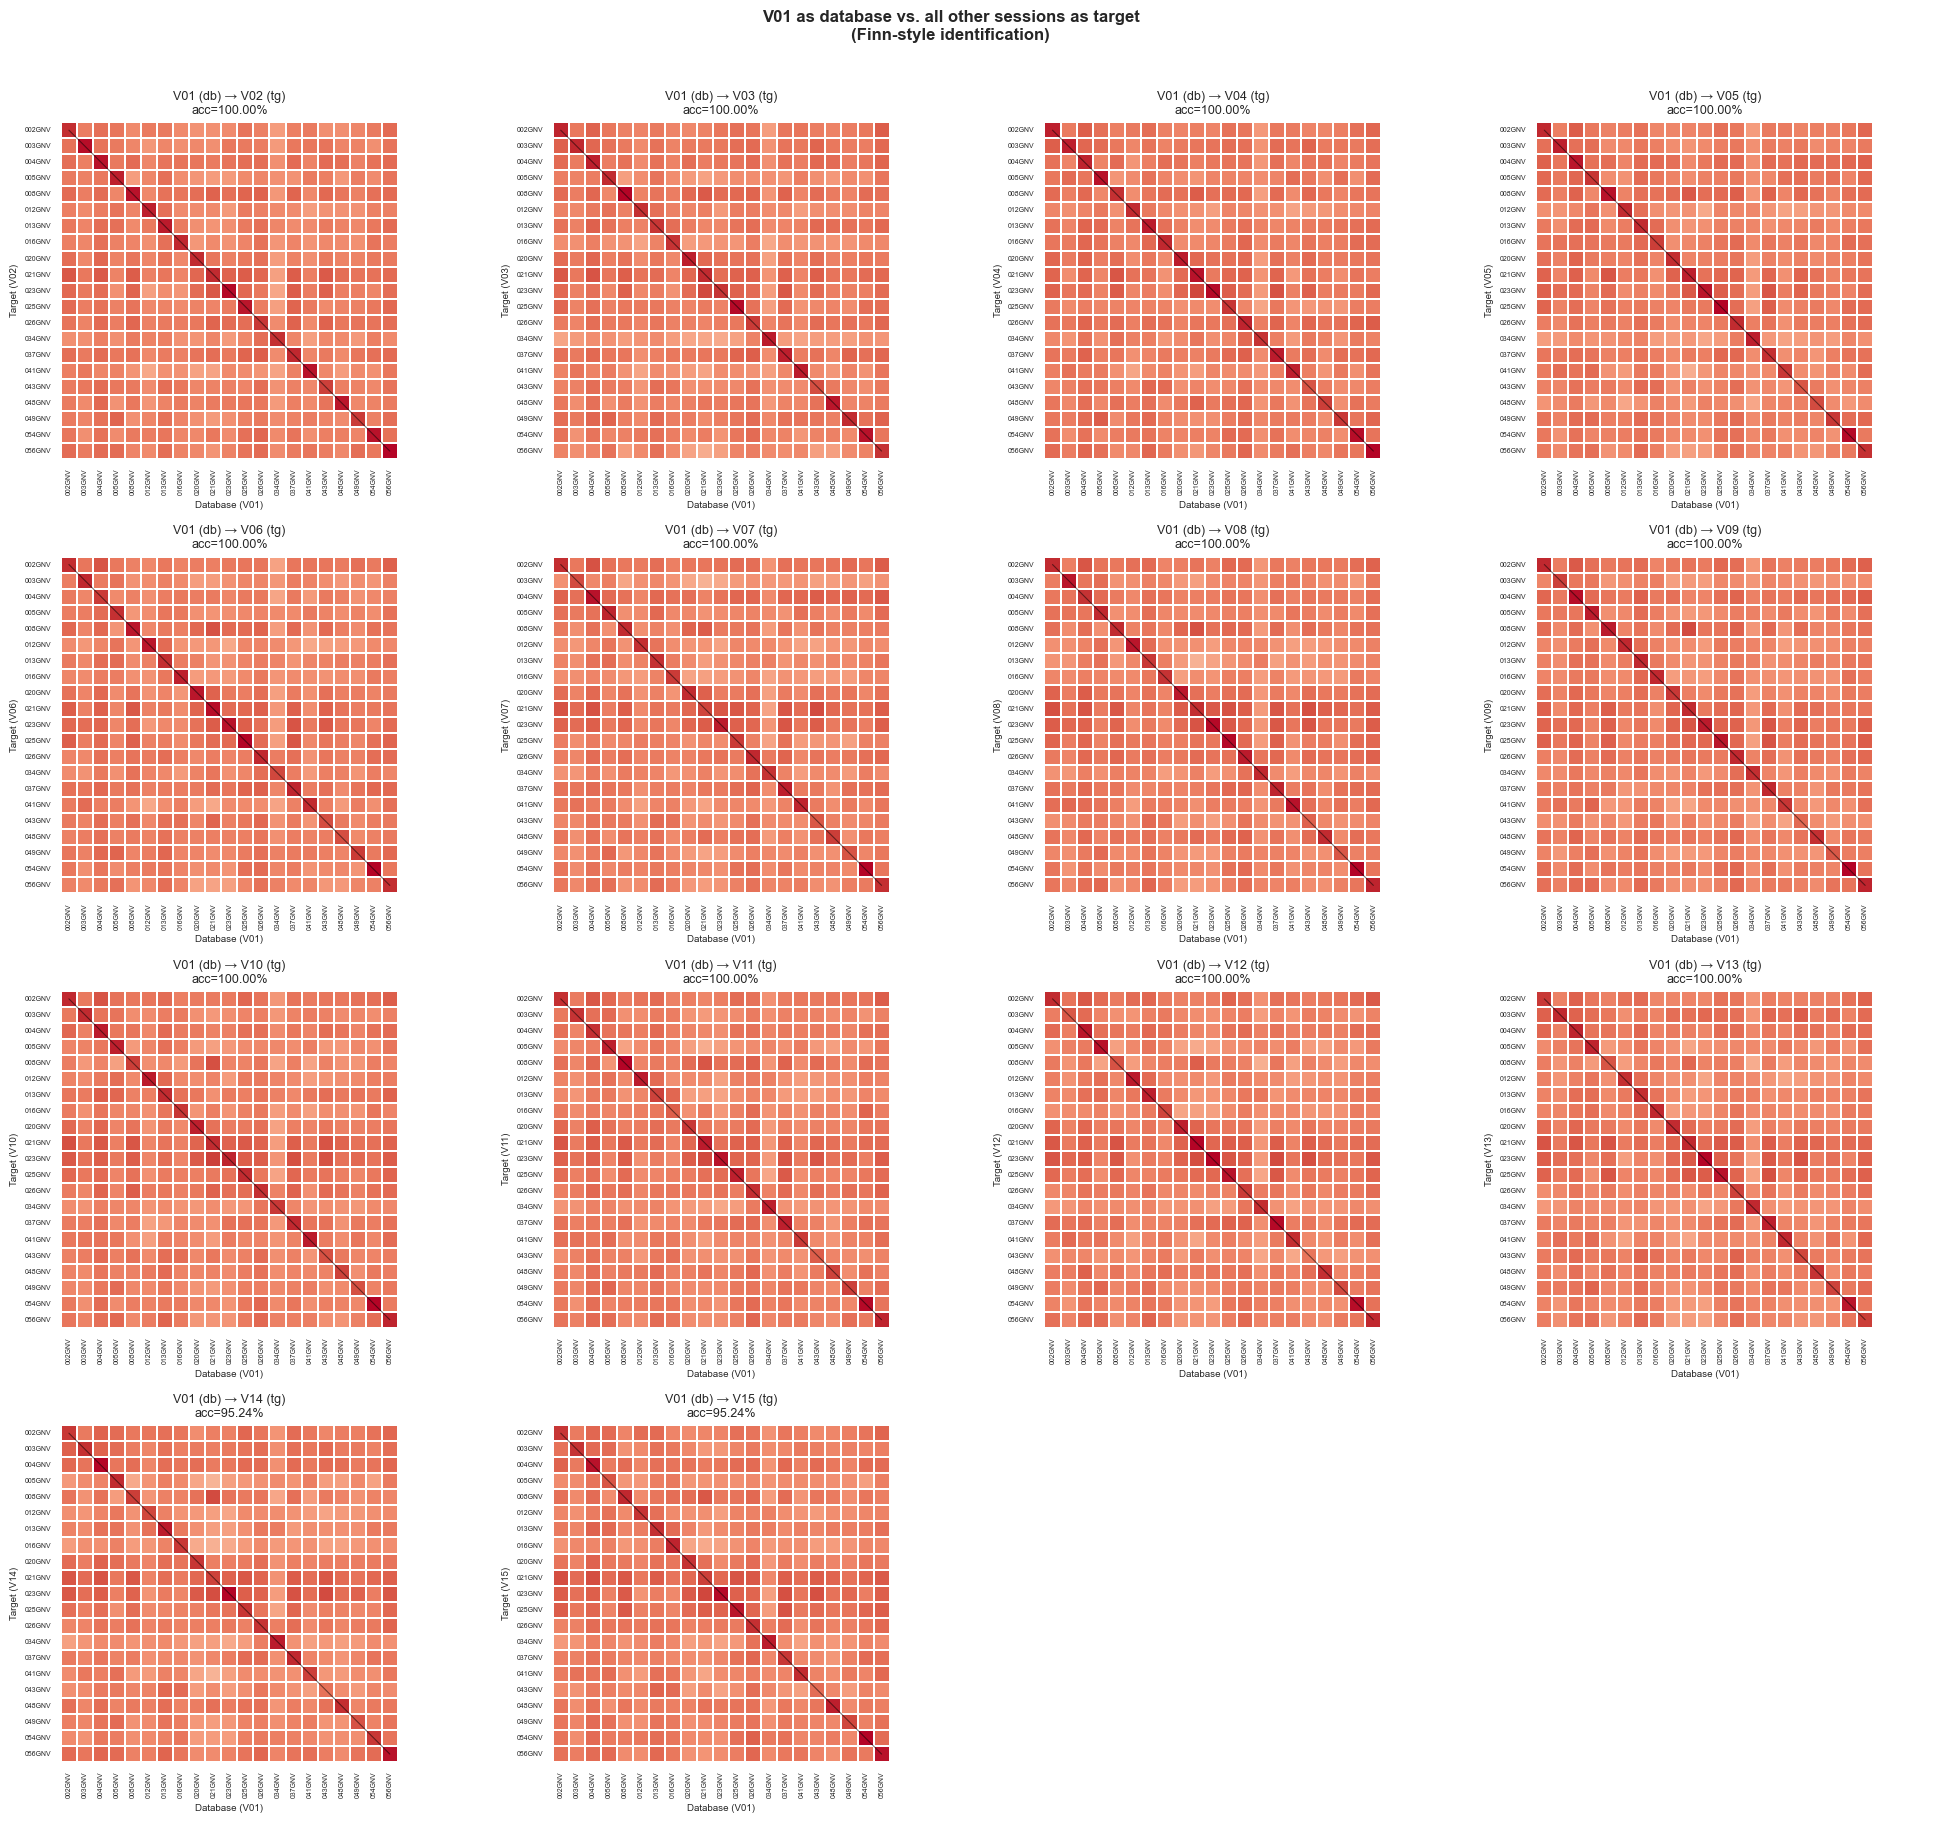

In [61]:
sessions = sorted(fc_df['session'].unique())
other_sessions = [s for s in sessions if s != 'V01']

n_pairs = len(other_sessions)  # 14 pairs
n_cols = 4
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5 * n_cols, 4.5 * n_rows),
                          squeeze=False)

for i, tg_sess in enumerate(other_sessions):
    row = i // n_cols
    col = i % n_cols
    ax  = axes[row, col]

    acc, sim, tg_labels, pred_labels = identification_accuracy_per_session(
        fc_df,
        db_session='V01',
        tg_session=tg_sess,
        label_col='subject'
    )

    # reorder rows and cols to follow sorted subject order
    subjects = sorted(np.unique(tg_labels))
    row_order = np.array([np.where(tg_labels == s)[0][0] for s in subjects])

    # get db label order
    _, _, db_labels_raw, _ = identification_accuracy_per_session(
        fc_df, db_session='V01', tg_session='V01', label_col='subject'
    )
    col_order = np.array([np.where(db_labels_raw == s)[0][0] for s in subjects])

    sim_ordered = sim[row_order][:, col_order]

    sns.heatmap(
        sim_ordered,
        ax=ax,
        cmap='coolwarm',
        center=0,
        vmin=sim_ordered.min(),
        vmax=sim_ordered.max(),
        square=True,
        linewidths=0.3,
        linecolor='white',
        xticklabels=subjects,
        yticklabels=subjects,
        cbar=False,
    )

    ax.set_title(f'V01 (db) → {tg_sess} (tg)\nacc={acc:.2%}', fontsize=9)
    ax.set_xlabel('Database (V01)', fontsize=7)
    ax.set_ylabel(f'Target ({tg_sess})', fontsize=7)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=5)

    # highlight diagonal
    n = sim_ordered.shape[0]
    ax.plot(np.arange(n) + 0.5, np.arange(n) + 0.5,
            color='black', lw=0.8, alpha=0.5)

# turn off unused axes
for j in range(i + 1, n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis('off')

fig.suptitle('V01 as database vs. all other sessions as target\n(Finn-style identification)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'v01_vs_all_sessions_identification.png'), dpi=300, bbox_inches='tight')
plt.show()

Run-level identification accuracy V01 → V15: 94.74%


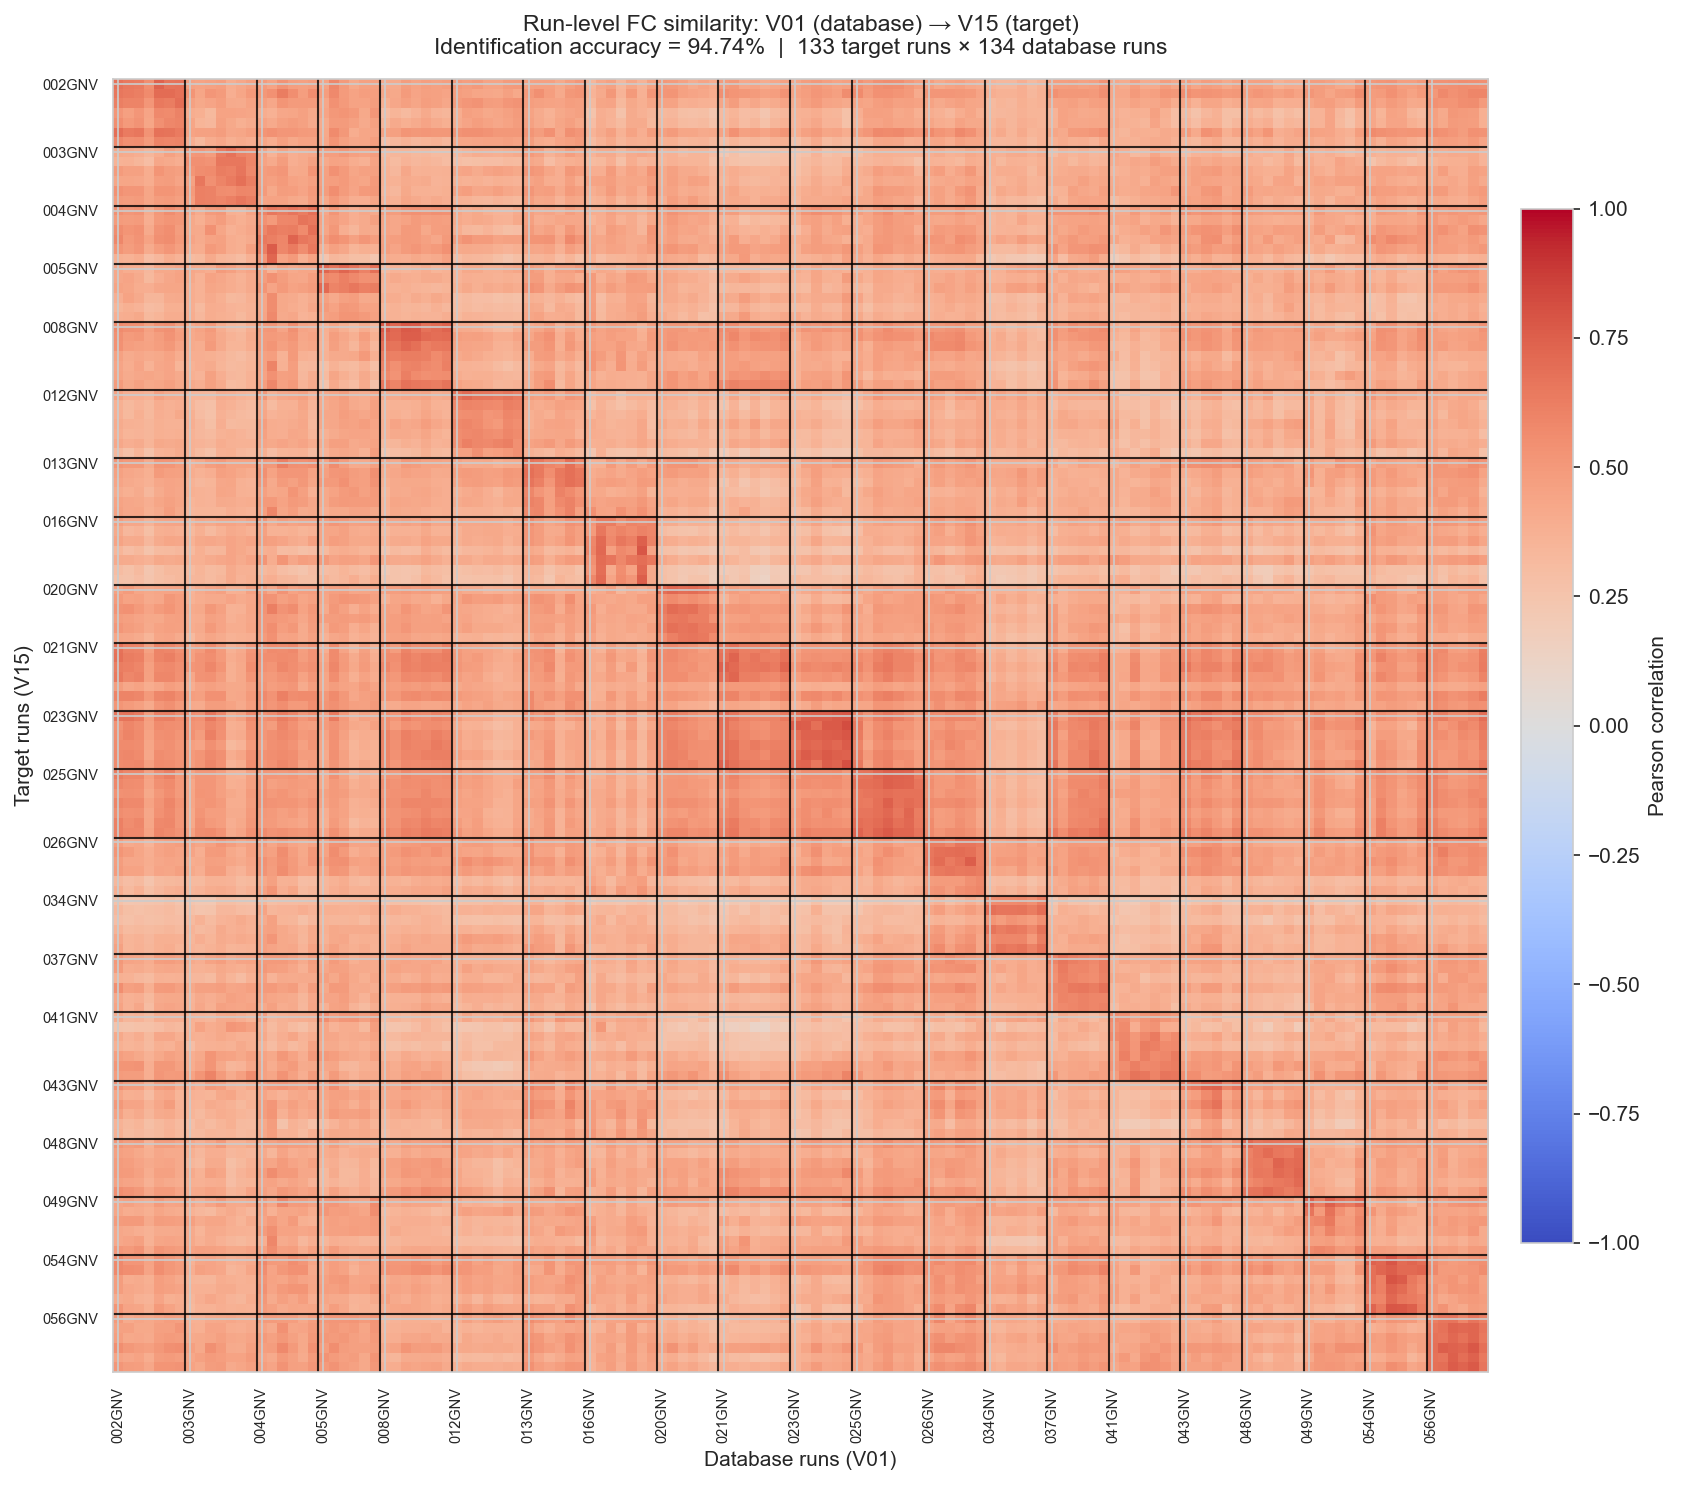

In [62]:
db_sess = 'V01'
tg_sess = 'V15'

# ── Build per-run FC matrices ─────────────────────────────────────────────────
db_df = fc_df[fc_df['session'] == db_sess].sort_values(['subject', 'run']).reset_index(drop=True)
tg_df = fc_df[fc_df['session'] == tg_sess].sort_values(['subject', 'run']).reset_index(drop=True)

db_mat = np.vstack(db_df['fc_vec'].values)   # (N_db_runs, E)
tg_mat = np.vstack(tg_df['fc_vec'].values)   # (N_tg_runs, E)

sim = similarity_corr(tg_mat, db_mat)         # (N_tg_runs, N_db_runs)

# ── Identification accuracy at run level ──────────────────────────────────────
db_labels = db_df['subject'].values
tg_labels = tg_df['subject'].values

predicted = db_labels[sim.argmax(axis=1)]
acc = (predicted == tg_labels).mean()
print(f"Run-level identification accuracy V01 → V15: {acc:.2%}")

# ── Tick labels: subject ID at first run of each subject ─────────────────────
def make_subject_ticks(labels_series):
    tick_pos    = []
    tick_labels = []
    for i, subj in enumerate(labels_series):
        if i == 0 or labels_series[i] != labels_series[i - 1]:
            tick_pos.append(i)
            tick_labels.append(subj)
    return tick_pos, tick_labels

db_tick_pos, db_tick_labels = make_subject_ticks(db_labels)
tg_tick_pos, tg_tick_labels = make_subject_ticks(tg_labels)

# ── Subject boundary lines ────────────────────────────────────────────────────
db_boundaries = [i for i in range(1, len(db_labels)) if db_labels[i] != db_labels[i-1]]
tg_boundaries = [i for i in range(1, len(tg_labels)) if tg_labels[i] != tg_labels[i-1]]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

im = ax.imshow(
    sim,
    cmap='coolwarm',
    vmin=-1.0,
    vmax=1.0,
    aspect='auto',
    interpolation='none'
)

# subject boundary lines on rows (target = V15)
for b in tg_boundaries:
    ax.axhline(b - 0.5, color='black', linewidth=1.0, alpha=0.8)

# subject boundary lines on cols (database = V01)
for b in db_boundaries:
    ax.axvline(b - 0.5, color='black', linewidth=1.0, alpha=0.8)

# ticks
ax.set_yticks(tg_tick_pos)
ax.set_yticklabels(tg_tick_labels, fontsize=7)
ax.set_xticks(db_tick_pos)
ax.set_xticklabels(db_tick_labels, rotation=90, fontsize=7)

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Pearson correlation', fontsize=10)

ax.set_xlabel(f'Database runs ({db_sess})', fontsize=10)
ax.set_ylabel(f'Target runs ({tg_sess})', fontsize=10)
ax.set_title(
    f'Run-level FC similarity: {db_sess} (database) → {tg_sess} (target)\n'
    f'Identification accuracy = {acc:.2%}  |  '
    f'{len(tg_df)} target runs × {len(db_df)} database runs',
    fontsize=11, pad=12
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'run_level_similarity_{db_sess}_vs_{tg_sess}.png'), dpi=300, bbox_inches='tight')
plt.show()

## Per-Subject Differential Identifiability

### What is this analysis?

For each subject, we quantify **how uniquely identifiable** their functional connectivity (FC) fingerprint is across sessions (V01 → V15).

We use the **session-level similarity matrix** `sim` (N_subjects × N_subjects), where each cell `sim[i, j]` is the Pearson correlation between:
- subject **i**'s FC vector in the **target session** (V15)
- subject **j**'s FC vector in the **database session** (V01)

After reordering rows and columns to follow sorted subject order, `sim[i, i]` is guaranteed to be the **within-subject** similarity (same person, different session).

---

### Metrics computed per subject

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **I_self** | `sim[i, i]` | How similar is my V15 FC to my own V01 FC? Higher = more stable fingerprint over time |
| **I_others** | `mean(sim[i, j] for j ≠ i)` | How similar am I on average to everyone else? Higher = my FC pattern is more typical |
| **best_impostor** | `argmax(sim[i, j] for j ≠ i)` | Which other subject looks most like me? |
| **best_impostor_sim** | `max(sim[i, j] for j ≠ i)` | How similar is that closest competitor? |
| **I_diff** | `I_self − I_others` | Core fingerprinting measure: how much more similar I am to myself than to the average other person |
| **margin** | `I_self − best_impostor_sim` | Safety gap above the single closest competitor. **Negative = would be misidentified** |

---

### Example with 3 subjects

Similarity matrix (V15 as target, V01 as database):

|  | sub01_V01 | sub02_V01 | sub03_V01 |
|--|-----------|-----------|-----------|
| **sub01_V15** | **0.84** | 0.55 | 0.49 |
| **sub02_V15** | 0.52 | **0.79** | 0.61 |
| **sub03_V15** | 0.48 | 0.58 | **0.83** |

For **sub01**:
- `I_self` = 0.84 (diagonal)
- `I_others` = (0.55 + 0.49) / 2 = 0.52
- `best_impostor` = sub02 (similarity = 0.55)
- `I_diff` = 0.84 − 0.52 = **0.32**
- `margin` = 0.84 − 0.55 = **0.29** ✓ correctly identified

---

### Interpreting the results

- **Large I_diff + large margin** → highly identifiable subject, FC fingerprint is both stable and distinct from others
- **Large I_diff + small margin** → identifiable on average, but one specific other subject looks very similar
- **Small I_diff** → FC fingerprint is not very distinct; subject looks similar to many others
- **Negative margin** → the subject's best impostor correlates *more* with their V01 FC than their own V15 FC does → **would be misidentified**

---

### Note on ordering
The raw `sim` matrix returned by `identification_accuracy_per_session` is **not guaranteed to be sorted by subject**. Before computing per-subject metrics, rows and columns are explicitly reordered so that `sim[i, i]` corresponds to subject `i` in the sorted subject list.

In [63]:
# Recompute session-level similarity matrix (sim was overwritten by run-level analysis above)
acc_s, sim_s, tg_labels_s, _ = identification_accuracy_per_session(
    fc_df, db_session='V01', tg_session='V15', label_col='subject'
)
_, _, db_labels_s, _ = identification_accuracy_per_session(
    fc_df, db_session='V01', tg_session='V01', label_col='subject'
)
subjects = sorted(np.unique(tg_labels_s))
n_subj = len(subjects)
row_order = np.array([np.where(tg_labels_s == s)[0][0] for s in subjects])
col_order = np.array([np.where(db_labels_s == s)[0][0] for s in subjects])
sim = sim_s[row_order][:, col_order]  # (N_subj, N_subj), sim[i,i] = subject i vs itself

rows = []
for i, subj in enumerate(subjects):
    i_self   = sim[i, i]
    off_diag = [(subjects[j], sim[i, j]) for j in range(n_subj) if j != i]
    off_diag.sort(key=lambda x: -x[1])  # sort by similarity descending
    
    best_impostor_id,  best_impostor_sim  = off_diag[0]   # most similar other subject
    worst_impostor_id, worst_impostor_sim = off_diag[-1]  # most different other subject
    
    i_others = np.mean([sim_val for _, sim_val in off_diag])
    i_diff   = i_self - i_others
    margin   = i_self - best_impostor_sim

    rows.append({
        'subject':            subj,
        'I_self':             i_self,
        'I_others':           i_others,
        'best_impostor':      best_impostor_id,    # ← who
        'best_impostor_sim':  best_impostor_sim,   # ← how similar
        'I_diff':             i_diff,
        'margin':             margin,
    })

idiff_df = pd.DataFrame(rows).sort_values('I_diff', ascending=False)
print(idiff_df.to_string(index=False))

subject   I_self  I_others best_impostor  best_impostor_sim   I_diff    margin
 016GNV 0.836935  0.474852        013GNV           0.559867 0.362083  0.277068
 034GNV 0.843987  0.484779        026GNV           0.598079 0.359209  0.245909
 054GNV 0.885723  0.564847        026GNV           0.660697 0.320876  0.225026
 056GNV 0.858120  0.554710        026GNV           0.642130 0.303411  0.215991
 048GNV 0.839697  0.550524        021GNV           0.601217 0.289173  0.238480
 041GNV 0.821424  0.534045        056GNV           0.631148 0.287379  0.190276
 012GNV 0.797246  0.511916        013GNV           0.603618 0.285330  0.193628
 004GNV 0.859858  0.586872        002GNV           0.654140 0.272986  0.205718
 023GNV 0.876898  0.617350        021GNV           0.745449 0.259548  0.131449
 008GNV 0.824477  0.566523        021GNV           0.686209 0.257954  0.138269
 003GNV 0.795987  0.539345        004GNV           0.625319 0.256642  0.170669
 013GNV 0.803765  0.553672        004GNV           0

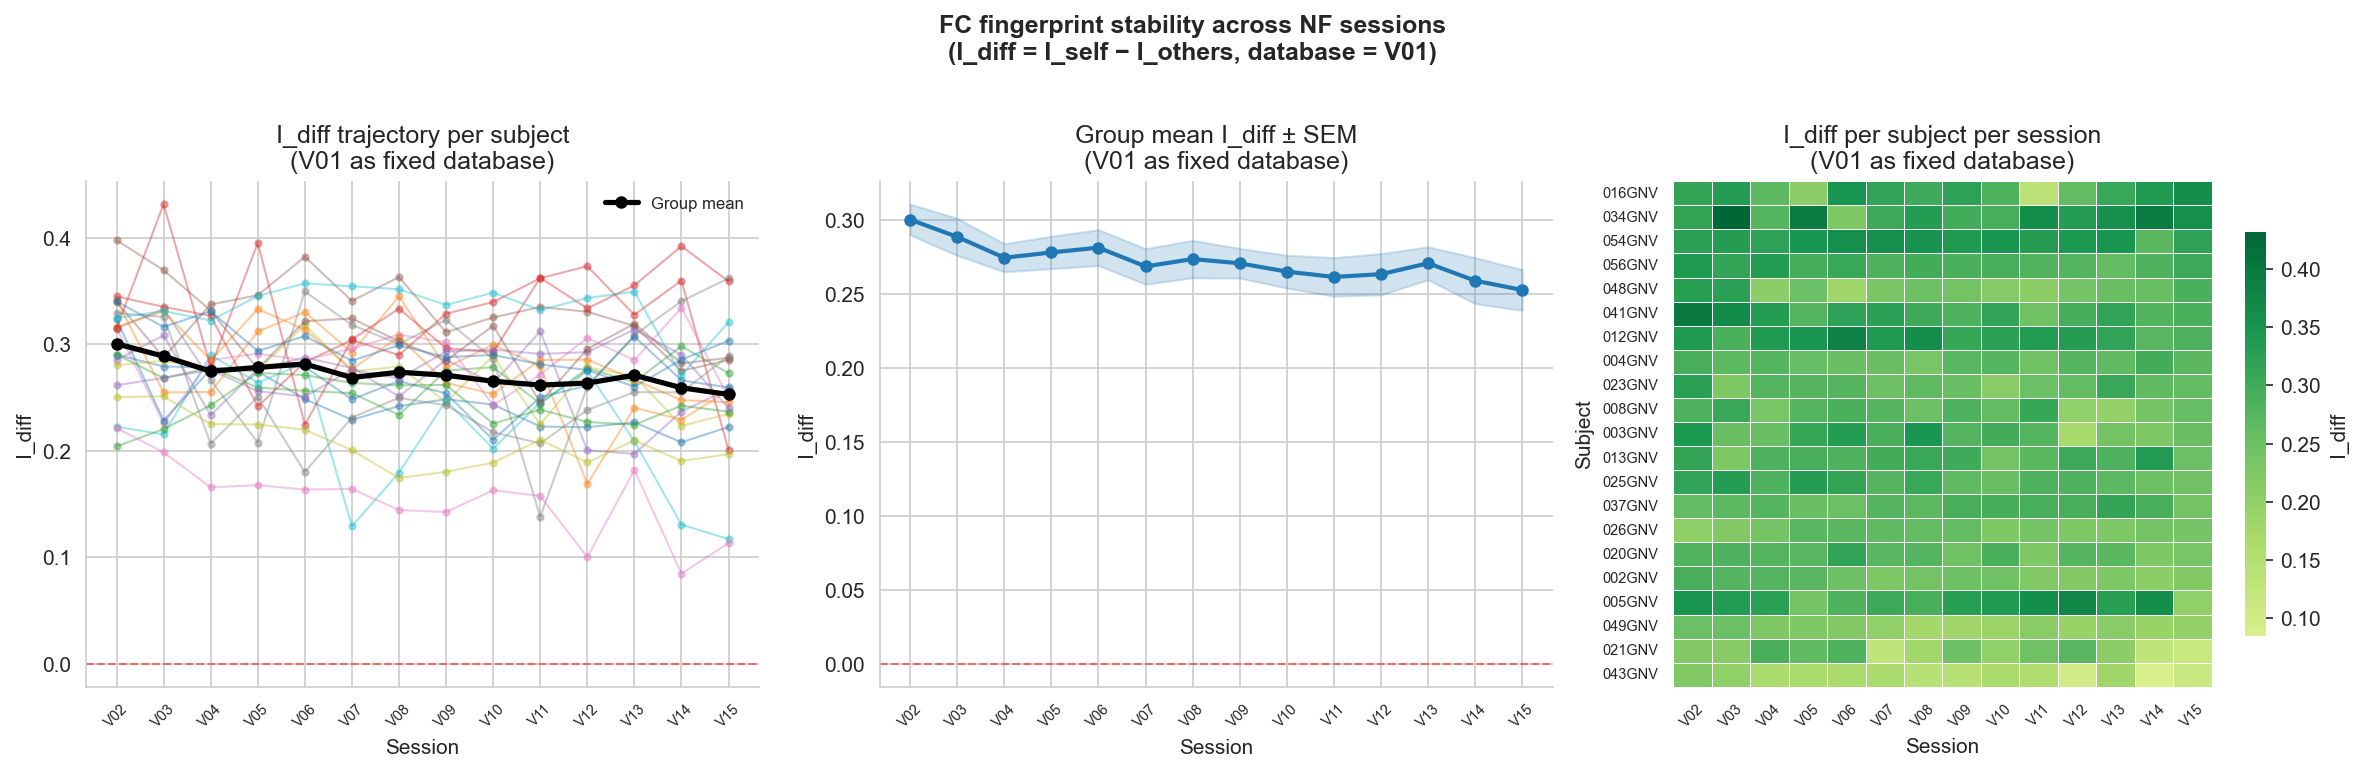

In [64]:
sessions = sorted(fc_df['session'].unique())
other_sessions = [s for s in sessions if s != 'V01']

# ── PASS 1: compute I_diff per subject per session ────────────────────────────
records = []

for tg_sess in other_sessions:
    acc, sim, tg_labels, _ = identification_accuracy_per_session(
        fc_df, db_session='V01', tg_session=tg_sess, label_col='subject'
    )

    # reorder sim so sim[i,i] = subject i vs itself
    _, _, db_labels, _ = identification_accuracy_per_session(
        fc_df, db_session='V01', tg_session='V01', label_col='subject'
    )
    subjects  = sorted(np.unique(tg_labels))
    row_order = np.array([np.where(tg_labels == s)[0][0] for s in subjects])
    col_order = np.array([np.where(db_labels == s)[0][0] for s in subjects])
    sim_ord   = sim[row_order][:, col_order]

    for i, subj in enumerate(subjects):
        i_self   = sim_ord[i, i]
        off_diag = np.delete(sim_ord[i], i)
        i_others = off_diag.mean()
        i_diff   = i_self - i_others

        records.append({
            'subject':     subj,
            'session':     tg_sess,
            'session_num': int(tg_sess.replace('V', '')),
            'I_self':      i_self,
            'I_others':    i_others,
            'I_diff':      i_diff,
        })

idiff_long = pd.DataFrame(records)

# ── PASS 2: plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=150)

# ── Plot 1: individual subject trajectories ───────────────────────────────────
ax = axes[0]
for subj, grp in idiff_long.groupby('subject'):
    grp = grp.sort_values('session_num')
    ax.plot(grp['session_num'], grp['I_diff'],
            alpha=0.4, linewidth=1, marker='o', markersize=3)

# group mean
group_mean = idiff_long.groupby('session_num')['I_diff'].mean().reset_index()
ax.plot(group_mean['session_num'], group_mean['I_diff'],
        color='black', linewidth=2.5, marker='o', markersize=5,
        label='Group mean', zorder=5)

ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Session')
ax.set_ylabel('I_diff')
ax.set_title('I_diff trajectory per subject\n(V01 as fixed database)')
ax.set_xticks(range(2, 16))
ax.set_xticklabels([f'V{n:02d}' for n in range(2, 16)], rotation=45, fontsize=7)
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# ── Plot 2: group mean ± SEM ──────────────────────────────────────────────────
ax = axes[1]
group_stats = (
    idiff_long.groupby('session_num')['I_diff']
    .agg(mean='mean', sem=lambda x: x.sem())
    .reset_index()
)
ax.plot(group_stats['session_num'], group_stats['mean'],
        color='C0', linewidth=2, marker='o', markersize=5)
ax.fill_between(group_stats['session_num'],
                group_stats['mean'] - group_stats['sem'],
                group_stats['mean'] + group_stats['sem'],
                alpha=0.2, color='C0')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Session')
ax.set_ylabel('I_diff')
ax.set_title('Group mean I_diff ± SEM\n(V01 as fixed database)')
ax.set_xticks(range(2, 16))
ax.set_xticklabels([f'V{n:02d}' for n in range(2, 16)], rotation=45, fontsize=7)
ax.spines[['top', 'right']].set_visible(False)

# ── Plot 3: heatmap — subject × session ──────────────────────────────────────
ax = axes[2]
pivot = idiff_long.pivot(index='subject', columns='session_num', values='I_diff')
pivot = pivot.sort_values(pivot.columns[-1], ascending=False)  # sort by last session

sns.heatmap(
    pivot,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'I_diff', 'shrink': 0.8},
    xticklabels=[f'V{n:02d}' for n in pivot.columns],
)
ax.set_title('I_diff per subject per session\n(V01 as fixed database)')
ax.set_xlabel('Session')
ax.set_ylabel('Subject')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('FC fingerprint stability across NF sessions\n(I_diff = I_self − I_others, database = V01)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'idiff_trajectory_across_sessions.png'), dpi=300, bbox_inches='tight')
plt.show()

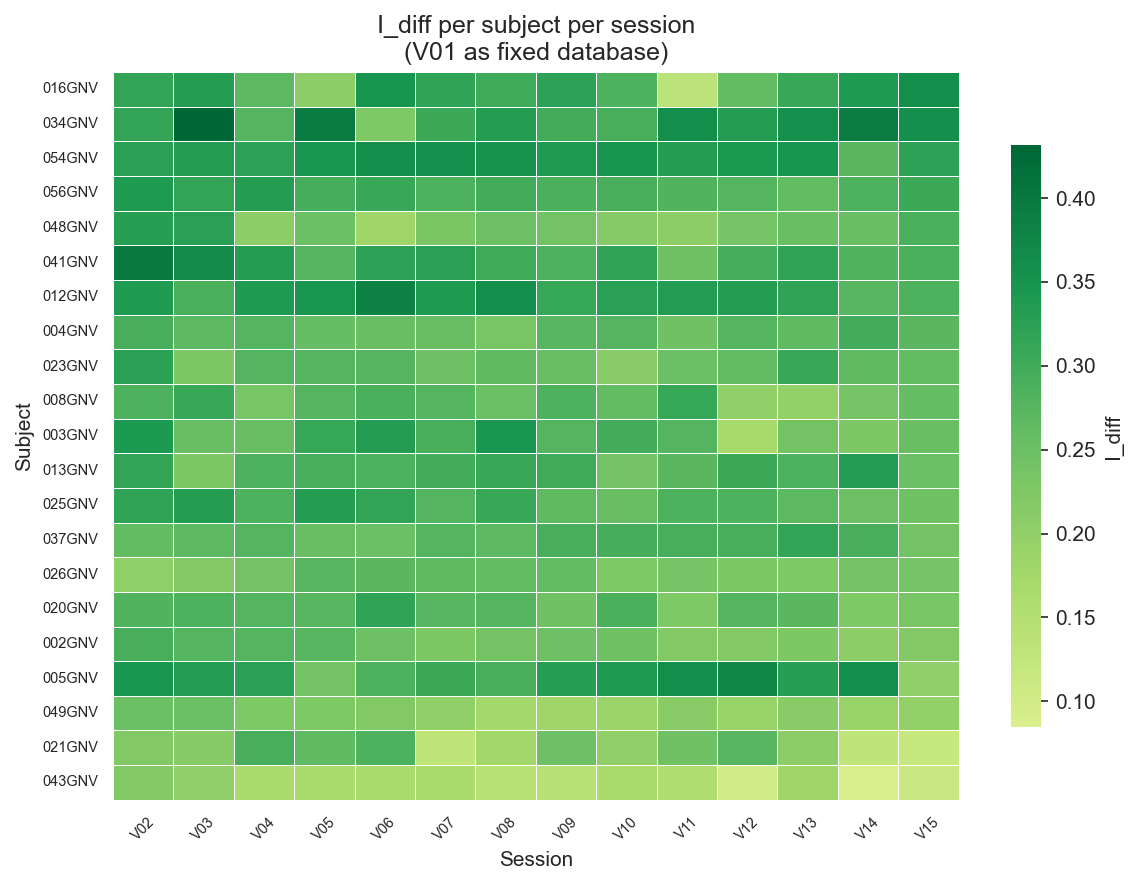

In [65]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

pivot = idiff_long.pivot(index='subject', columns='session_num', values='I_diff')
pivot = pivot.sort_values(pivot.columns[-1], ascending=False)

sns.heatmap(
    pivot,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'I_diff', 'shrink': 0.8},
    xticklabels=[f'V{n:02d}' for n in pivot.columns],
)
ax.set_title('I_diff per subject per session\n(V01 as fixed database)')
ax.set_xlabel('Session')
ax.set_ylabel('Subject')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'idiff_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
